In [1]:
import scipy.linalg as la
import numpy as np
import copy
import time
import random
import matplotlib.pyplot as plt
import pandas as pd
import csv, ast
from qutip import *
import numpy as np
import yfinance as yf
from datetime import datetime
import scienceplots
from fitting_model import *
from ESN_model import *
from extracter import *
from rollover import * 
rng = np.random.default_rng(43)
np.random.seed(43)
random.seed(43)

import matplotlib.pyplot as plt
import matplotlib as mpl

# Global plotting style for manuscript figures
mpl.rcParams.update({
    "font.family": "Arial",          
    "font.size": 8,

    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,

    "lines.linewidth": 1.5,
    "lines.markersize": 4,

    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,

    "pdf.fonttype": 42,   
    "ps.fonttype": 42,
    "svg.fonttype": "none"
})

In [9]:
import hashlib

## 3 data
prices = yf.download(
    "AAPL",
    start="2014-01-01",
    end="2024-01-01",
    auto_adjust=False
)

prices.to_csv("AAPL_2014_2024.csv")
filename = "AAPL_2014_2024.csv"

with open(filename, "rb") as f:
    sha256 = hashlib.sha256(f.read()).hexdigest()

print(sha256)

[*********************100%***********************]  1 of 1 completed

9174ff2e04154e1700fcad082c02bddc51baa147eb709285a24f5d4ad807edca


In [13]:
import hashlib

## 3 data
prices = yf.download(
    "^GSPC",
    start="2014-01-01",
    end="2024-01-01",
    auto_adjust=False
)

prices.to_csv("GSPC_2014_2024.csv")
filename = "GSPC_2014_2024.csv"

with open(filename, "rb") as f:
    sha256 = hashlib.sha256(f.read()).hexdigest()

print(sha256)

[*********************100%***********************]  1 of 1 completed

ff06cd89ee7ed7209f227f81f67a22743fc5180b20af22b1058116c953e7a974


In [15]:
import hashlib

## 3 data
prices = yf.download(
    "^IXIC",
    start="2014-01-01",
    end="2024-01-01",
    auto_adjust=False
)

prices.to_csv("IXIC_2014_2024.csv")
filename = "IXIC_2014_2024.csv"

with open(filename, "rb") as f:
    sha256 = hashlib.sha256(f.read()).hexdigest()

print(sha256)

[*********************100%***********************]  1 of 1 completed

1cb4fcbfd92c5e6984d4036b13b9aebd3da17a3d04c6e1c5354870ba7e33b1c8


Analyzing different mode collecting methods.

We analyze whether collecting two quadratures and one quadrature assissting in performance.
- When no mask is applied
- When masked is applied

C:\Users\Phi Hung Nguyen\AppData\Local\Temp\ipykernel_8692\2096645062.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download('^GSPC',start=f"{2014}-01-01",end=f"{2024}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed


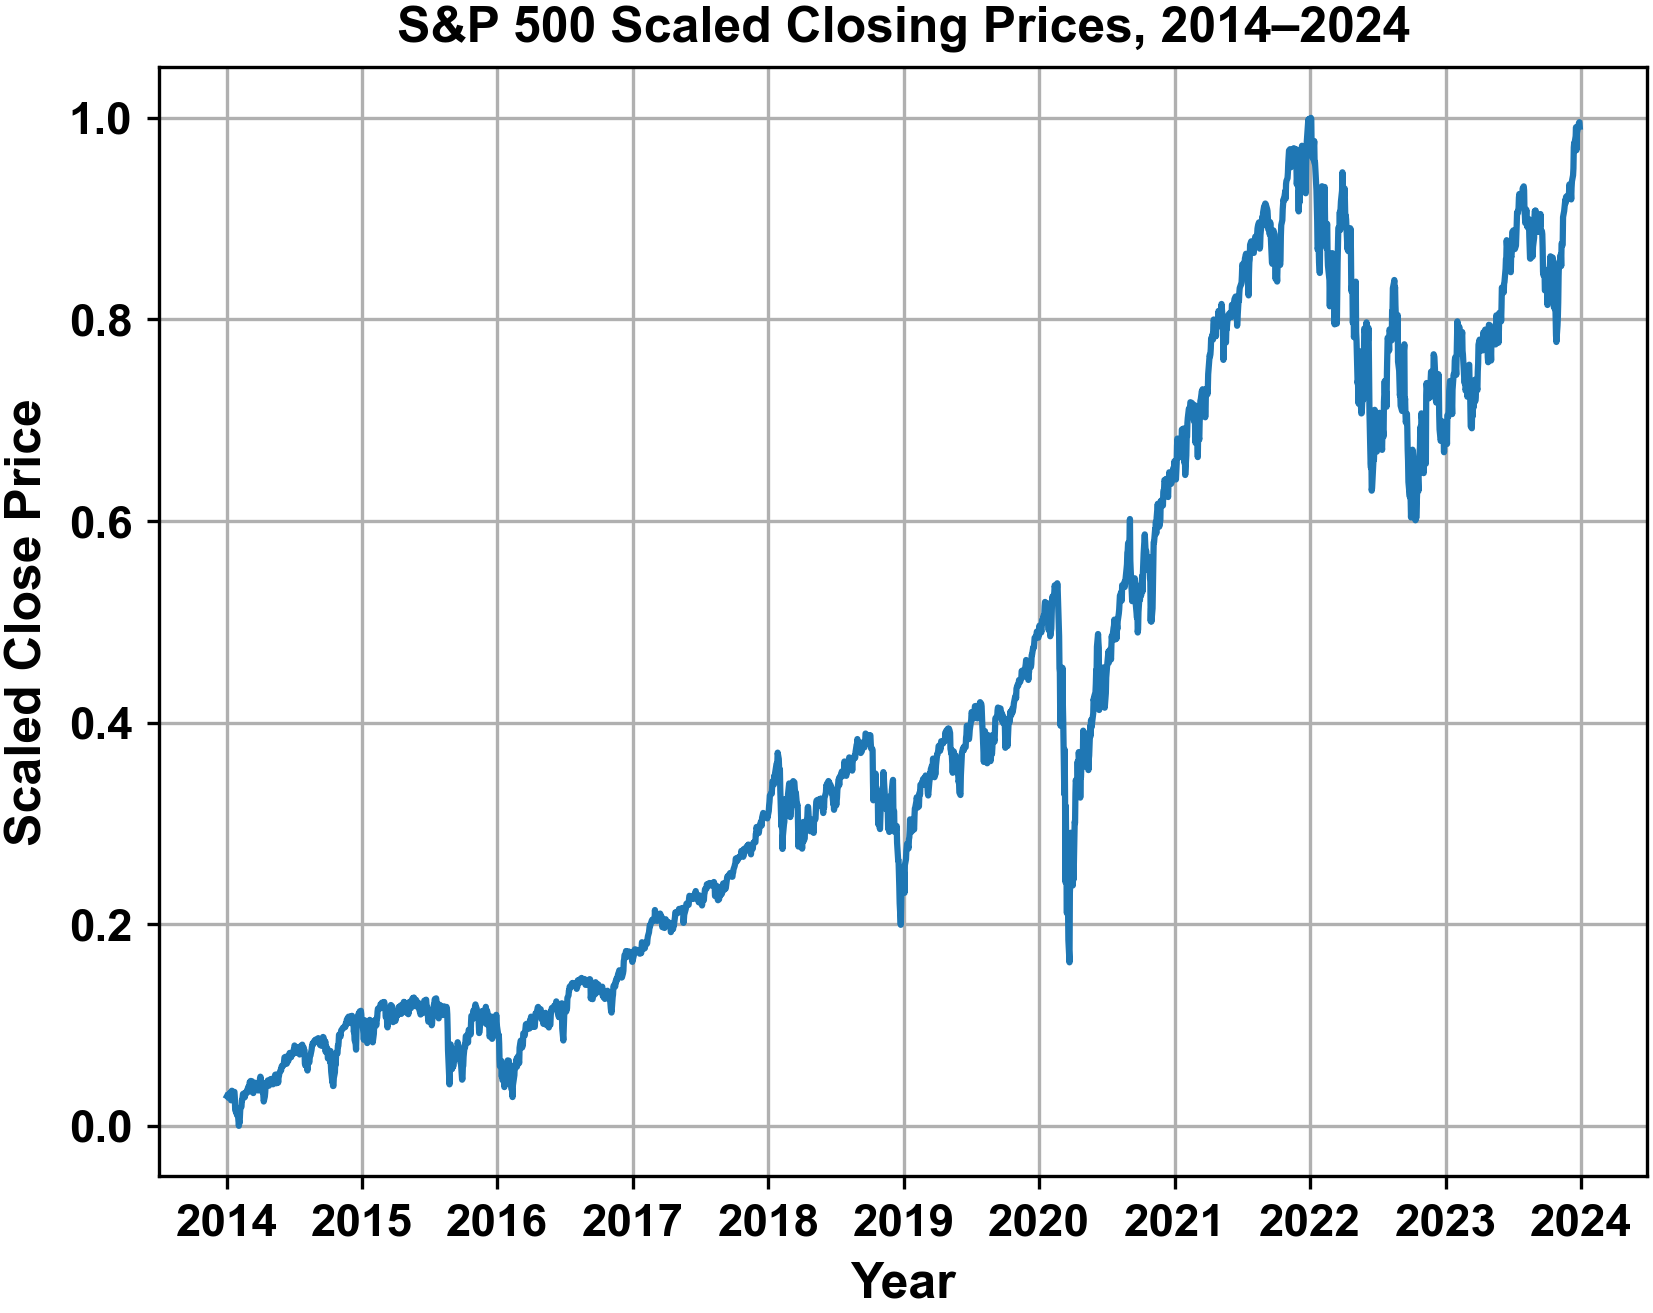

In [4]:
prices = yf.download('^GSPC',start=f"{2014}-01-01",end=f"{2024}-01-01")["Close"]
dataset = prices.values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset).flatten()
plt.plot(prices.index, scaled_data)

plt.xlabel("Year")
plt.ylabel("Scaled Close Price")
plt.title("S&P 500 Scaled Closing Prices, 2014–2024")

plt.grid(True)
plt.savefig('SP500')
plt.show()

In [5]:
N=15
rep=1
name = 'SP500'

In [6]:
df = pd.read_csv(f"{name}_Features_2014_2024_rep{rep}_tau{N}.csv")
X_p = extract_delayed_p_or_q_single_column(df,column_name="PQ-15",N=N,repeat_steps=rep) # extract only p
X_p.shape

(2516, 15)

In [7]:
X_pq = extract_delayed_single_column(df,column_name="PQ-15",N=N*2,repeat_steps=rep) # extract both p and q
X_pq.shape

(2516, 30)

In [8]:
column_names = [f"PQ-{i}" for i in range(N-1, 0, -1)] + ["PQ0"]
X_p_row = extract_p_row(df,column_names=column_names,repeat_steps=rep,keep_last=True) # extract p for each row
X_p_row.shape

(2516, 15)

In [9]:
start = 2014
end = 2024
name = '^GSPC'
resultpq, errorspq = rollover(start, end, name, X_pq, tau=1, Nfading=10)
resultp, errorsp = rollover(start, end, name, X_p, tau=1, Nfading=10)
resultp_row, errorsp_row = rollover(start, end, name, X_p_row, tau=1, Nfading=10)

C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(name,start=f"{start}-01-01",end=f"{end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_2yr = yf.download(name,start=f"{train_start}-01-01",end=f"{train_end}-01-01")["Close"]
[*********************100%**********************

Final result:
NRMSE values: [0.04086036 0.12795231 0.12448866 0.08743403 0.14566189 0.36240463
 0.29191463 0.10673517]
Mean NRMSE: 0.16093145851310414
Std NRMSE: 0.10899087096526623



C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_2yr = yf.download(name,start=f"{train_start}-01-01",end=f"{train_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
[*********************100%******

Final result:
NRMSE values: [0.10916621 0.21785978 0.1096961  0.08171031 0.10223216 0.44856538
 0.18867778 0.11631377]
Mean NRMSE: 0.17177768725287598
Std NRMSE: 0.12119634559771361



C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_2yr = yf.download(name,start=f"{train_start}-01-01",end=f"{train_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
[*********************100%******

Final result:
NRMSE values: [0.06555301 0.17255014 0.10880898 0.06654018 0.11459594 0.9330236
 0.4167001  0.18254254]
Mean NRMSE: 0.257539309968832
Std NRMSE: 0.29528479865252066


In [10]:
print('Performance of PQ: ', errorspq)
print('Performance of P: ', errorsp)
print('Performance of Prow: ', errorsp_row)

Performance of PQ:  [0.04086036 0.12795231 0.12448866 0.08743403 0.14566189 0.36240463
 0.29191463 0.10673517]
Performance of P:  [0.10916621 0.21785978 0.1096961  0.08171031 0.10223216 0.44856538
 0.18867778 0.11631377]
Performance of Prow:  [0.06555301 0.17255014 0.10880898 0.06654018 0.11459594 0.9330236
 0.4167001  0.18254254]


In [11]:
tasks = ['^GSPC', 'AAPL', '^IXIC']
tasks_name = ['SP500', 'AAPL', 'NASDAQ']
start = 2014
end = 2024
reps = [1,10]
tau = 15
performance = {}
for rep in reps:
    for i in range(len(tasks)):
        csv_name = f'{tasks_name[i]}_Features_2014_2024_rep{rep}_tau{tau}.csv'
        df = pd.read_csv(csv_name)
        X_pq = extract_delayed_single_column(df,column_name=f"PQ-15",N=tau*2,repeat_steps=rep)
        results, errors = rollover(start, end, tasks[i], X_pq, tau=1, Nfading=10)
        performance[csv_name] = errors
        print(f'{tasks_name[i]} at rep {rep} and tau 15 has nrmse: ', errors)

C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(name,start=f"{start}-01-01",end=f"{end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_2yr = yf.download(name,start=f"{train_start}-01-01",end=f"{train_end}-01-01")["Close"]
[*********************100%**********************

Final result:
NRMSE values: [0.04086036 0.12795231 0.12448866 0.08743403 0.14566189 0.36240463
 0.29191463 0.10673517]
Mean NRMSE: 0.16093145851310414
Std NRMSE: 0.10899087096526623
SP500 at rep 1 and tau 15 has nrmse:  [0.04086036 0.12795231 0.12448866 0.08743403 0.14566189 0.36240463
 0.29191463 0.10673517]


[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_2yr = yf.download(name,start=f"{train_start}-01-01",end=f"{train_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01

Final result:
NRMSE values: [0.0552278  0.04050369 0.05973673 0.03890655 0.29574154 0.171459
 0.23455666 0.1962742 ]
Mean NRMSE: 0.13655077092584683
Std NRMSE: 0.10071571362719307
AAPL at rep 1 and tau 15 has nrmse:  [0.0552278  0.04050369 0.05973673 0.03890655 0.29574154 0.171459
 0.23455666 0.1962742 ]


[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_2yr = yf.download(name,start=f"{train_start}-01-01",end=f"{train_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01

...

Final result:
NRMSE values: [0.04076724 0.10483575 0.05571228 0.0338171  0.04285708 0.20569997
 0.07637439 0.04126413]
Mean NRMSE: 0.07516599146612939
Std NRMSE: 0.057799565885848184
SP500 at rep 10 and tau 15 has nrmse:  [0.04076724 0.10483575 0.05571228 0.0338171  0.04285708 0.20569997
 0.07637439 0.04126413]


C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(name,start=f"{start}-01-01",end=f"{end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_2yr = yf.download(name,start=f"{train_start}-01-01",end=f"{train_end}-01-01")["Close"]
[*********************100%**********************

Final result:
NRMSE values: [0.05332094 0.03446674 0.04272275 0.0230209  0.07078328 0.10195339
 0.0769892  0.06593674]
Mean NRMSE: 0.058649243449883974
Std NRMSE: 0.025489947991352544
AAPL at rep 10 and tau 15 has nrmse:  [0.05332094 0.03446674 0.04272275 0.0230209  0.07078328 0.10195339
 0.0769892  0.06593674]


C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(name,start=f"{start}-01-01",end=f"{end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_2yr = yf.download(name,start=f"{train_start}-01-01",end=f"{train_end}-01-01")["Close"]
[*********************100%**********************

Final result:
NRMSE values: [0.04156096 0.12689687 0.05621965 0.03424517 0.03946691 0.23575844
 0.06200417 0.03528498]
Mean NRMSE: 0.07892964553364798
Std NRMSE: 0.07025832619897154
NASDAQ at rep 10 and tau 15 has nrmse:  [0.04156096 0.12689687 0.05621965 0.03424517 0.03946691 0.23575844
 0.06200417 0.03528498]


In [12]:
tasks = ['^GSPC', 'AAPL', '^IXIC']
tasks_name = ['SP500', 'AAPL', 'NASDAQ']
esn_performance = run_esn_repeated(
    tasks=tasks,
    tasks_name=tasks_name,
    start=2014,
    end=2024,
    n_runs=100,
    N=30,
    tau=1,
    Nfading=10,
    input_scale=1.0,
    spectral_radius=0.95,
    connectivity=0.1,
)

C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:65: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(name,start=f"{start}-01-01",end=f"{end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:81: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:82: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_2yr = yf.download(name,start=f"{train_start}-01-01",end=f"{train_end}-01-01")["Close"]
[*********************100%*********************


Running ESN for SP500
Run 1/100
A norm 5.564633696543827
B norm 2.8660046383369004
A/B ratio 1.9415996827461173



C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:82: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_2yr = yf.download(name,start=f"{train_start}-01-01",end=f"{train_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:81: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:82: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_2yr = yf.download(name,start=f"{train_start}-01-01",end=f"{train_end}-01-01")["Close"]
[*********************100%*****

Final result
NRMSE values: [0.03817089 0.0395564  0.0546665  0.03492562 0.04422353 0.06006003
 0.05351446 0.03545024]
Mean NRMSE: 0.045070960523257465
Std NRMSE: 0.009726728393958895
Run 2/100
A norm 4.890158033044715
B norm 3.176466166733875
A/B ratio 1.5394963384964688



C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:82: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_2yr = yf.download(name,start=f"{train_start}-01-01",end=f"{train_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:81: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:82: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_2yr = yf.download(name,start=f"{train_start}-01-01",end=f"{train_end}-01-01")["Close"]
[*********************100%*****

...

Final result
NRMSE values: [0.04090749 0.10387756 0.05399102 0.03426323 0.09293525 0.07833699
 0.04656638 0.02956472]
Mean NRMSE: 0.06005533013963364
Std NRMSE: 0.02807126880512093
Run 99/100
A norm 4.593806496535134
B norm 2.7827726420094185
A/B ratio 1.6508019473764777



C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:81: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:82: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_2yr = yf.download(name,start=f"{train_start}-01-01",end=f"{train_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:81: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
[*********************100%******

Final result
NRMSE values: [0.04162002 0.0520323  0.05386093 0.03305261 0.05285163 0.09125951
 0.04693107 0.02998073]
Mean NRMSE: 0.0501986017043413
Std NRMSE: 0.01888623028545148
Run 100/100
A norm 5.774587020350031
B norm 2.8981111357331
A/B ratio 1.9925347061921088



C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:81: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:82: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_2yr = yf.download(name,start=f"{train_start}-01-01",end=f"{train_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:81: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
[*********************100%******

Final result
NRMSE values: [0.04169083 0.06490678 0.05731959 0.03609761 0.04339351 0.05874021
 0.04642958 0.02962656]
Mean NRMSE: 0.0472755823534198
Std NRMSE: 0.01211014526285087
NASDAQ ESN mean per fold: [0.04270043 0.1262898  0.05606651 0.03327079 0.11577649 0.12685517
 0.04663754 0.02974586]
NASDAQ ESN final mean NRMSE: 0.07216782404688063
NASDAQ ESN std across folds: 0.042951112939631136


In [13]:
reps = [1, 10]
tau_feature = 15
x = np.arange(len(tasks_name))
qr_rep1_errors = [performance[f"{task}_Features_2014_2024_rep1_tau{tau_feature}.csv"] for task in tasks_name]
qr_rep10_errors = [performance[f"{task}_Features_2014_2024_rep10_tau{tau_feature}.csv"] for task in tasks_name]

qr_rep1_means = np.array([np.mean(e) for e in qr_rep1_errors])
qr_rep1_stds  = np.array([np.std(e, ddof=1) for e in qr_rep1_errors])

qr_rep10_means = np.array([np.mean(e) for e in qr_rep10_errors])
qr_rep10_stds  = np.array([np.std(e, ddof=1) for e in qr_rep10_errors])

esn_means = np.array([esn_performance[task]["mean"] for task in tasks_name])
esn_stds = np.array([esn_performance[task]["std"] for task in tasks_name])

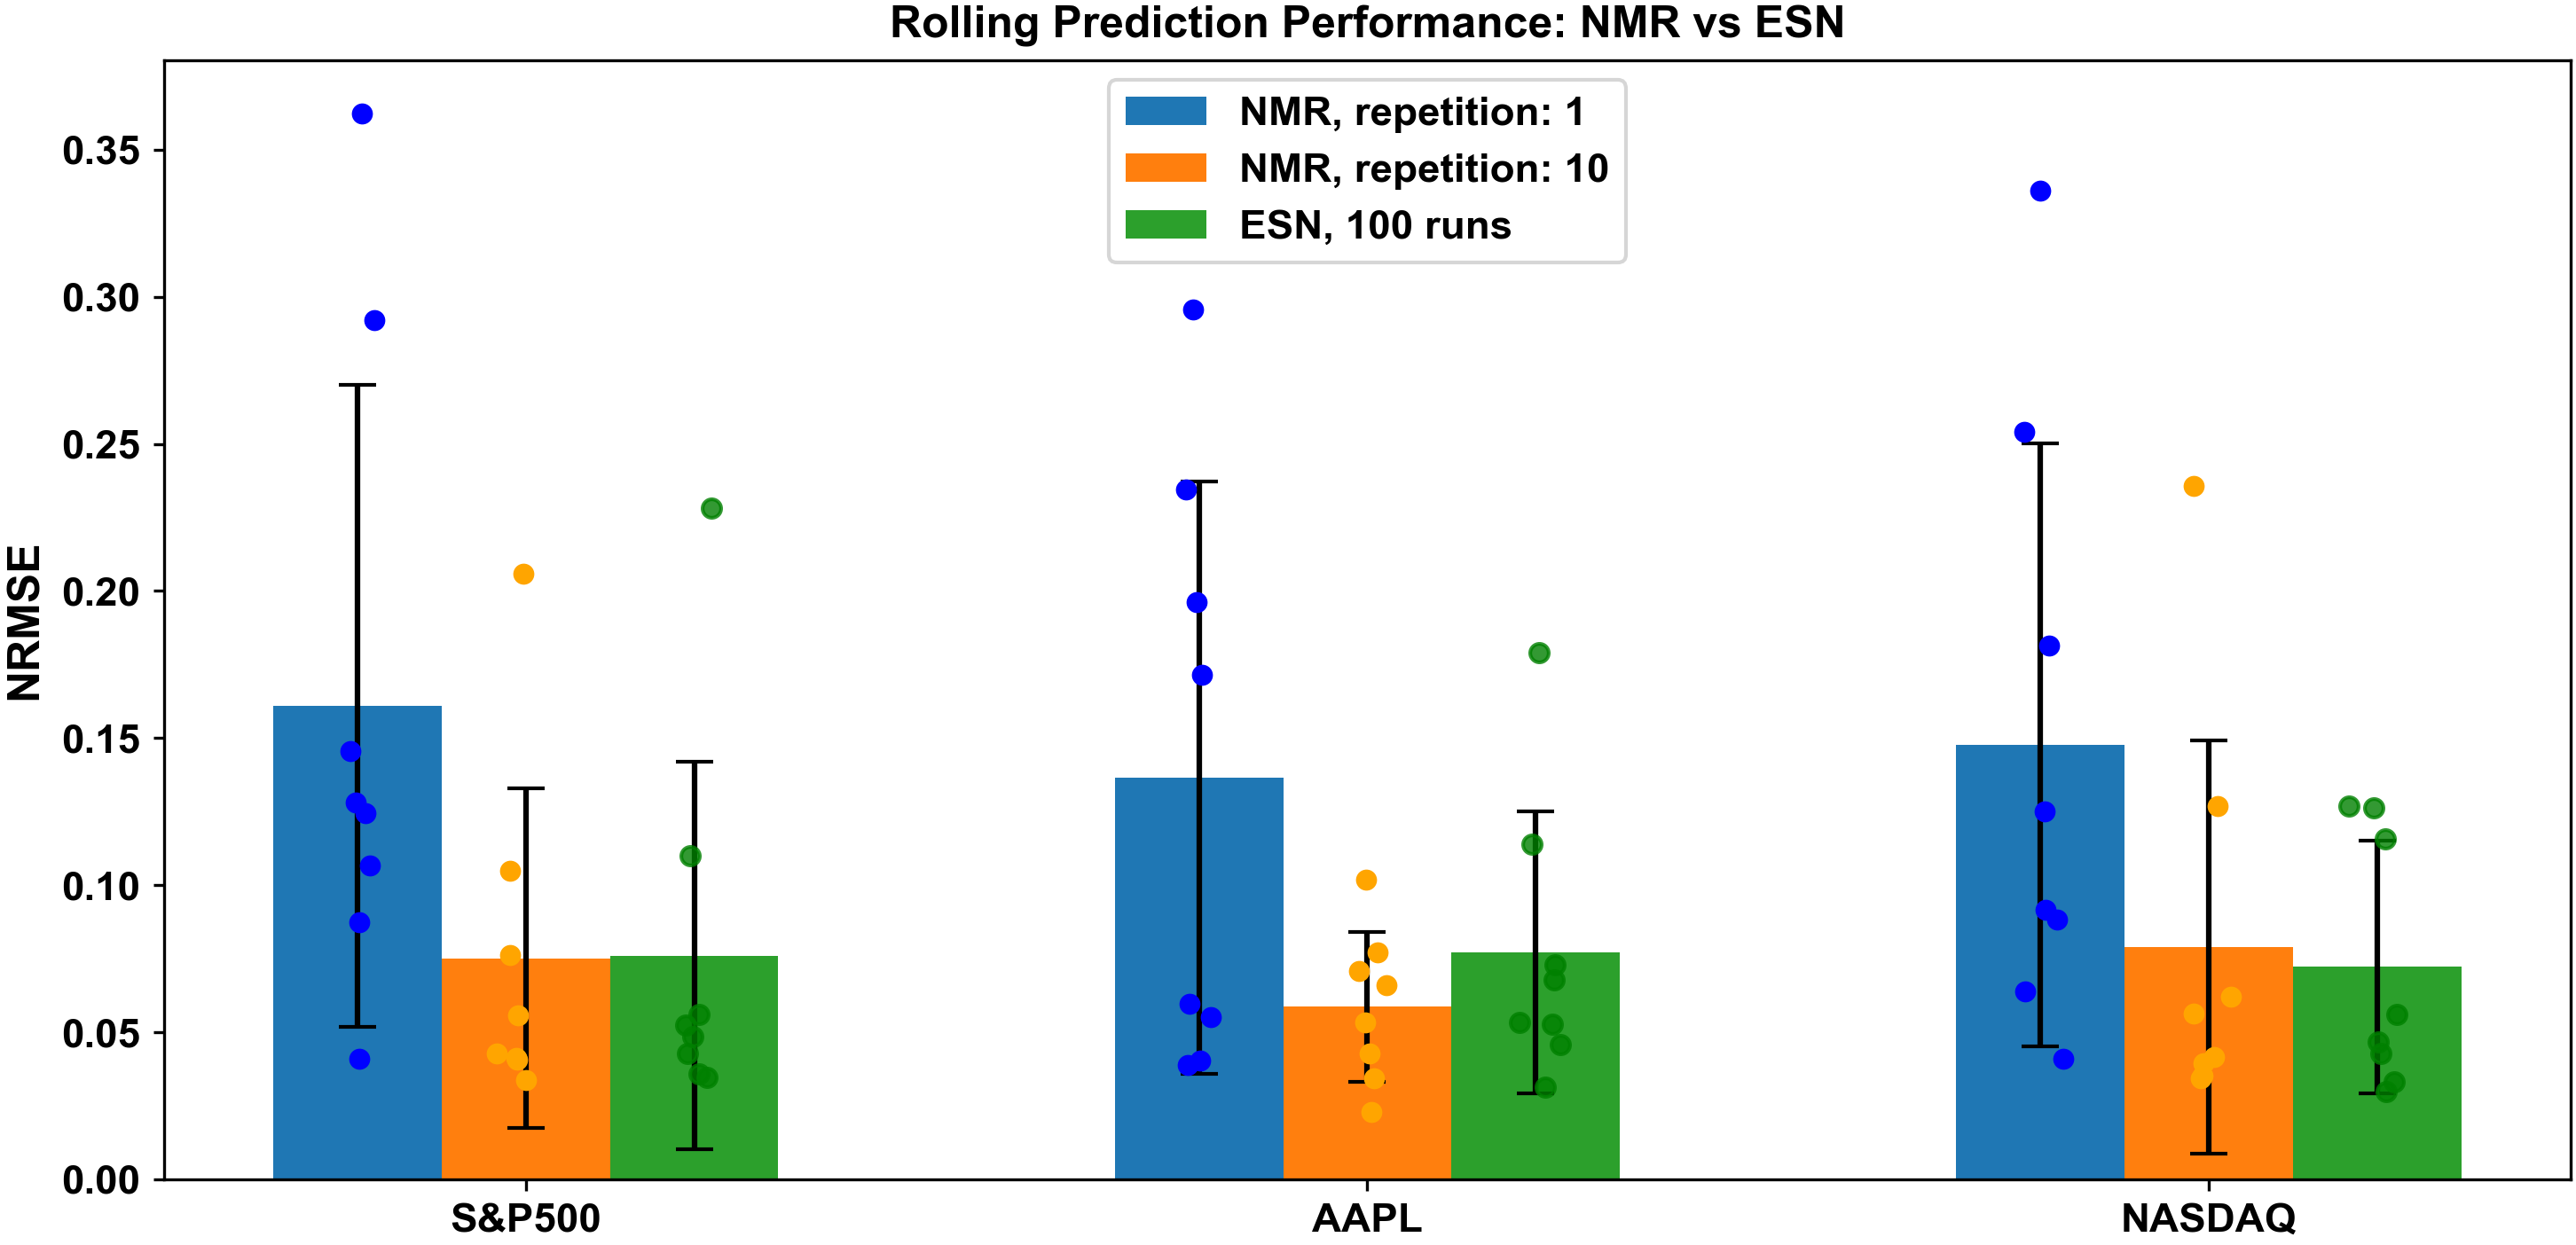

In [14]:
plt.figure(figsize=(10, 5))
tasks_name = ['SP500', 'AAPL', 'NASDAQ']
width = .2
plt.bar(x - width,qr_rep1_means,width,yerr=qr_rep1_stds,capsize=5,label="NMR, repetition: 1")
plt.bar(x,qr_rep10_means,width,yerr=qr_rep10_stds,capsize=5,label="NMR, repetition: 10")
plt.bar(x + width,esn_means,width,yerr=esn_stds,capsize=5,label="ESN, 100 runs")
rng = np.random.default_rng(0)
for i, task in enumerate(tasks_name):
    # QR rep = 1 rolling window points
    jitter = rng.normal(0, 0.015, size=len(qr_rep1_errors[i]))
    plt.scatter(np.full(len(qr_rep1_errors[i]), x[i] - width) + jitter,qr_rep1_errors[i],s=22,zorder=3,color="blue")
    # QR rep = 10 rolling window points
    jitter = rng.normal(0, 0.015, size=len(qr_rep10_errors[i]))
    plt.scatter(np.full(len(qr_rep10_errors[i]), x[i]) + jitter,qr_rep10_errors[i],s=22,zorder=3,color='orange')
    # ESN points: one point per rolling fold, averaged over 100 ESN runs
    esn_points = esn_performance[task]["mean_per_fold"]
    jitter = rng.normal(0, 0.015, size=len(esn_points))
    plt.scatter(np.full(len(esn_points), x[i] + width) + jitter,esn_points,s=25,alpha=0.8,zorder=3,color='green')
tasks_name2 = ['S&P500', 'AAPL', 'NASDAQ']
plt.xticks(x, tasks_name2)
plt.ylabel("NRMSE")
#plt.xlabel("Task")
plt.title("Rolling Prediction Performance: NMR vs ESN")
plt.legend()
plt.tight_layout()
plt.savefig('stockprediction.png')
plt.show()

In [41]:
print(qr_rep1_means, qr_rep1_stds)
print(qr_rep10_means,qr_rep10_stds)
print(esn_means, esn_stds)

[0.16093146 0.13655077 0.14769301] [0.10899087 0.10071571 0.10250482]
[0.07516599 0.05864924 0.07892965] [0.05779957 0.02548995 0.07025833]
[0.07603445 0.07710466 0.07216782] [0.06593003 0.04798921 0.04295111]


By varying the distance of the atom away from the mirror, we want to see how the performance changes. 

In [16]:
start = 2014
end = 2024
reps = [1,10]
taus = [5,10,15,20]
performance = {}
for rep in reps:
    for tau in taus:
        csv_name = f'SP500_Features_2014_2024_rep{rep}_tau{tau}.csv'
        df = pd.read_csv(csv_name)
        X_pq = extract_delayed_single_column(df,column_name=f"PQ-{tau}",N=tau*2,repeat_steps=rep)
        results, errors = rollover(start, end, '^GSPC', X_pq, tau=1, Nfading=10)
        performance[csv_name] = errors
        print(f'SP500 at rep {rep} and tau {tau} has nrmse: ', errors)

C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(name,start=f"{start}-01-01",end=f"{end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_2yr = yf.download(name,start=f"{train_start}-01-01",end=f"{train_end}-01-01")["Close"]
[*********************100%**********************

Final result:
NRMSE values: [0.04120042 0.11665127 0.11468563 0.07817026 0.11716624 0.53794036
 0.12567056 0.07589454]
Mean NRMSE: 0.15092240920876912
Std NRMSE: 0.15901869267462188
SP500 at rep 1 and tau 5 has nrmse:  [0.04120042 0.11665127 0.11468563 0.07817026 0.11716624 0.53794036
 0.12567056 0.07589454]



C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_2yr = yf.download(name,start=f"{train_start}-01-01",end=f"{train_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
[*********************100%******

Final result:
NRMSE values: [0.04126696 0.12743377 0.12123648 0.08654558 0.13877017 0.34294998
 0.20766123 0.09374572]
Mean NRMSE: 0.14495123549698108
Std NRMSE: 0.0932179927566953
SP500 at rep 1 and tau 10 has nrmse:  [0.04126696 0.12743377 0.12123648 0.08654558 0.13877017 0.34294998
 0.20766123 0.09374572]



C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_2yr = yf.download(name,start=f"{train_start}-01-01",end=f"{train_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_2yr = yf.download(name,start=f"{train_start}-01-01",end=f"{train_end}-01-01")["Close"]
[*********************100%*****

...

Final result:
NRMSE values: [0.04062226 0.06099455 0.0550223  0.03148029 0.04055408 0.05892739
 0.05463812 0.03622466]
Mean NRMSE: 0.04730795476675569
Std NRMSE: 0.011334173447762767
SP500 at rep 10 and tau 10 has nrmse:  [0.04062226 0.06099455 0.0550223  0.03148029 0.04055408 0.05892739
 0.05463812 0.03622466]


C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(name,start=f"{start}-01-01",end=f"{end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_2yr = yf.download(name,start=f"{train_start}-01-01",end=f"{train_end}-01-01")["Close"]
[*********************100%**********************

Final result:
NRMSE values: [0.04076724 0.10483575 0.05571228 0.0338171  0.04285708 0.20569997
 0.07637439 0.04126413]
Mean NRMSE: 0.07516599146612939
Std NRMSE: 0.057799565885848184
SP500 at rep 10 and tau 15 has nrmse:  [0.04076724 0.10483575 0.05571228 0.0338171  0.04285708 0.20569997
 0.07637439 0.04126413]


C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(name,start=f"{start}-01-01",end=f"{end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_3yr = yf.download(name,start=f"{train_start}-01-01",end=f"{test_end}-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\Phi Hung Nguyen\Dropbox\NonMarkovian_RC\NMI_nonMarkovian\StockMarketPrediction\rollover.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_2yr = yf.download(name,start=f"{train_start}-01-01",end=f"{train_end}-01-01")["Close"]
[*********************100%**********************

Final result:
NRMSE values: [0.04032277 0.11915084 0.06001048 0.03381435 0.04260028 0.3385205
 0.12160644 0.04975213]
Mean NRMSE: 0.10072222468078218
Std NRMSE: 0.10217778599763086
SP500 at rep 10 and tau 20 has nrmse:  [0.04032277 0.11915084 0.06001048 0.03381435 0.04260028 0.3385205
 0.12160644 0.04975213]


In [17]:
import numpy as np
import matplotlib.pyplot as plt

reps = [1, 10]
taus = [5, 10, 15, 20]

x = np.arange(len(taus))
rep1_errors = [performance[f"SP500_Features_2014_2024_rep1_tau{tau}.csv"] for tau in taus]
rep10_errors = [performance[f"SP500_Features_2014_2024_rep10_tau{tau}.csv"] for tau in taus]

rep1_means = np.array([np.mean(e) for e in rep1_errors])
rep1_stds  = np.array([np.std(e, ddof=1) for e in rep1_errors])

rep10_means = np.array([np.mean(e) for e in rep10_errors])
rep10_stds  = np.array([np.std(e, ddof=1) for e in rep10_errors])

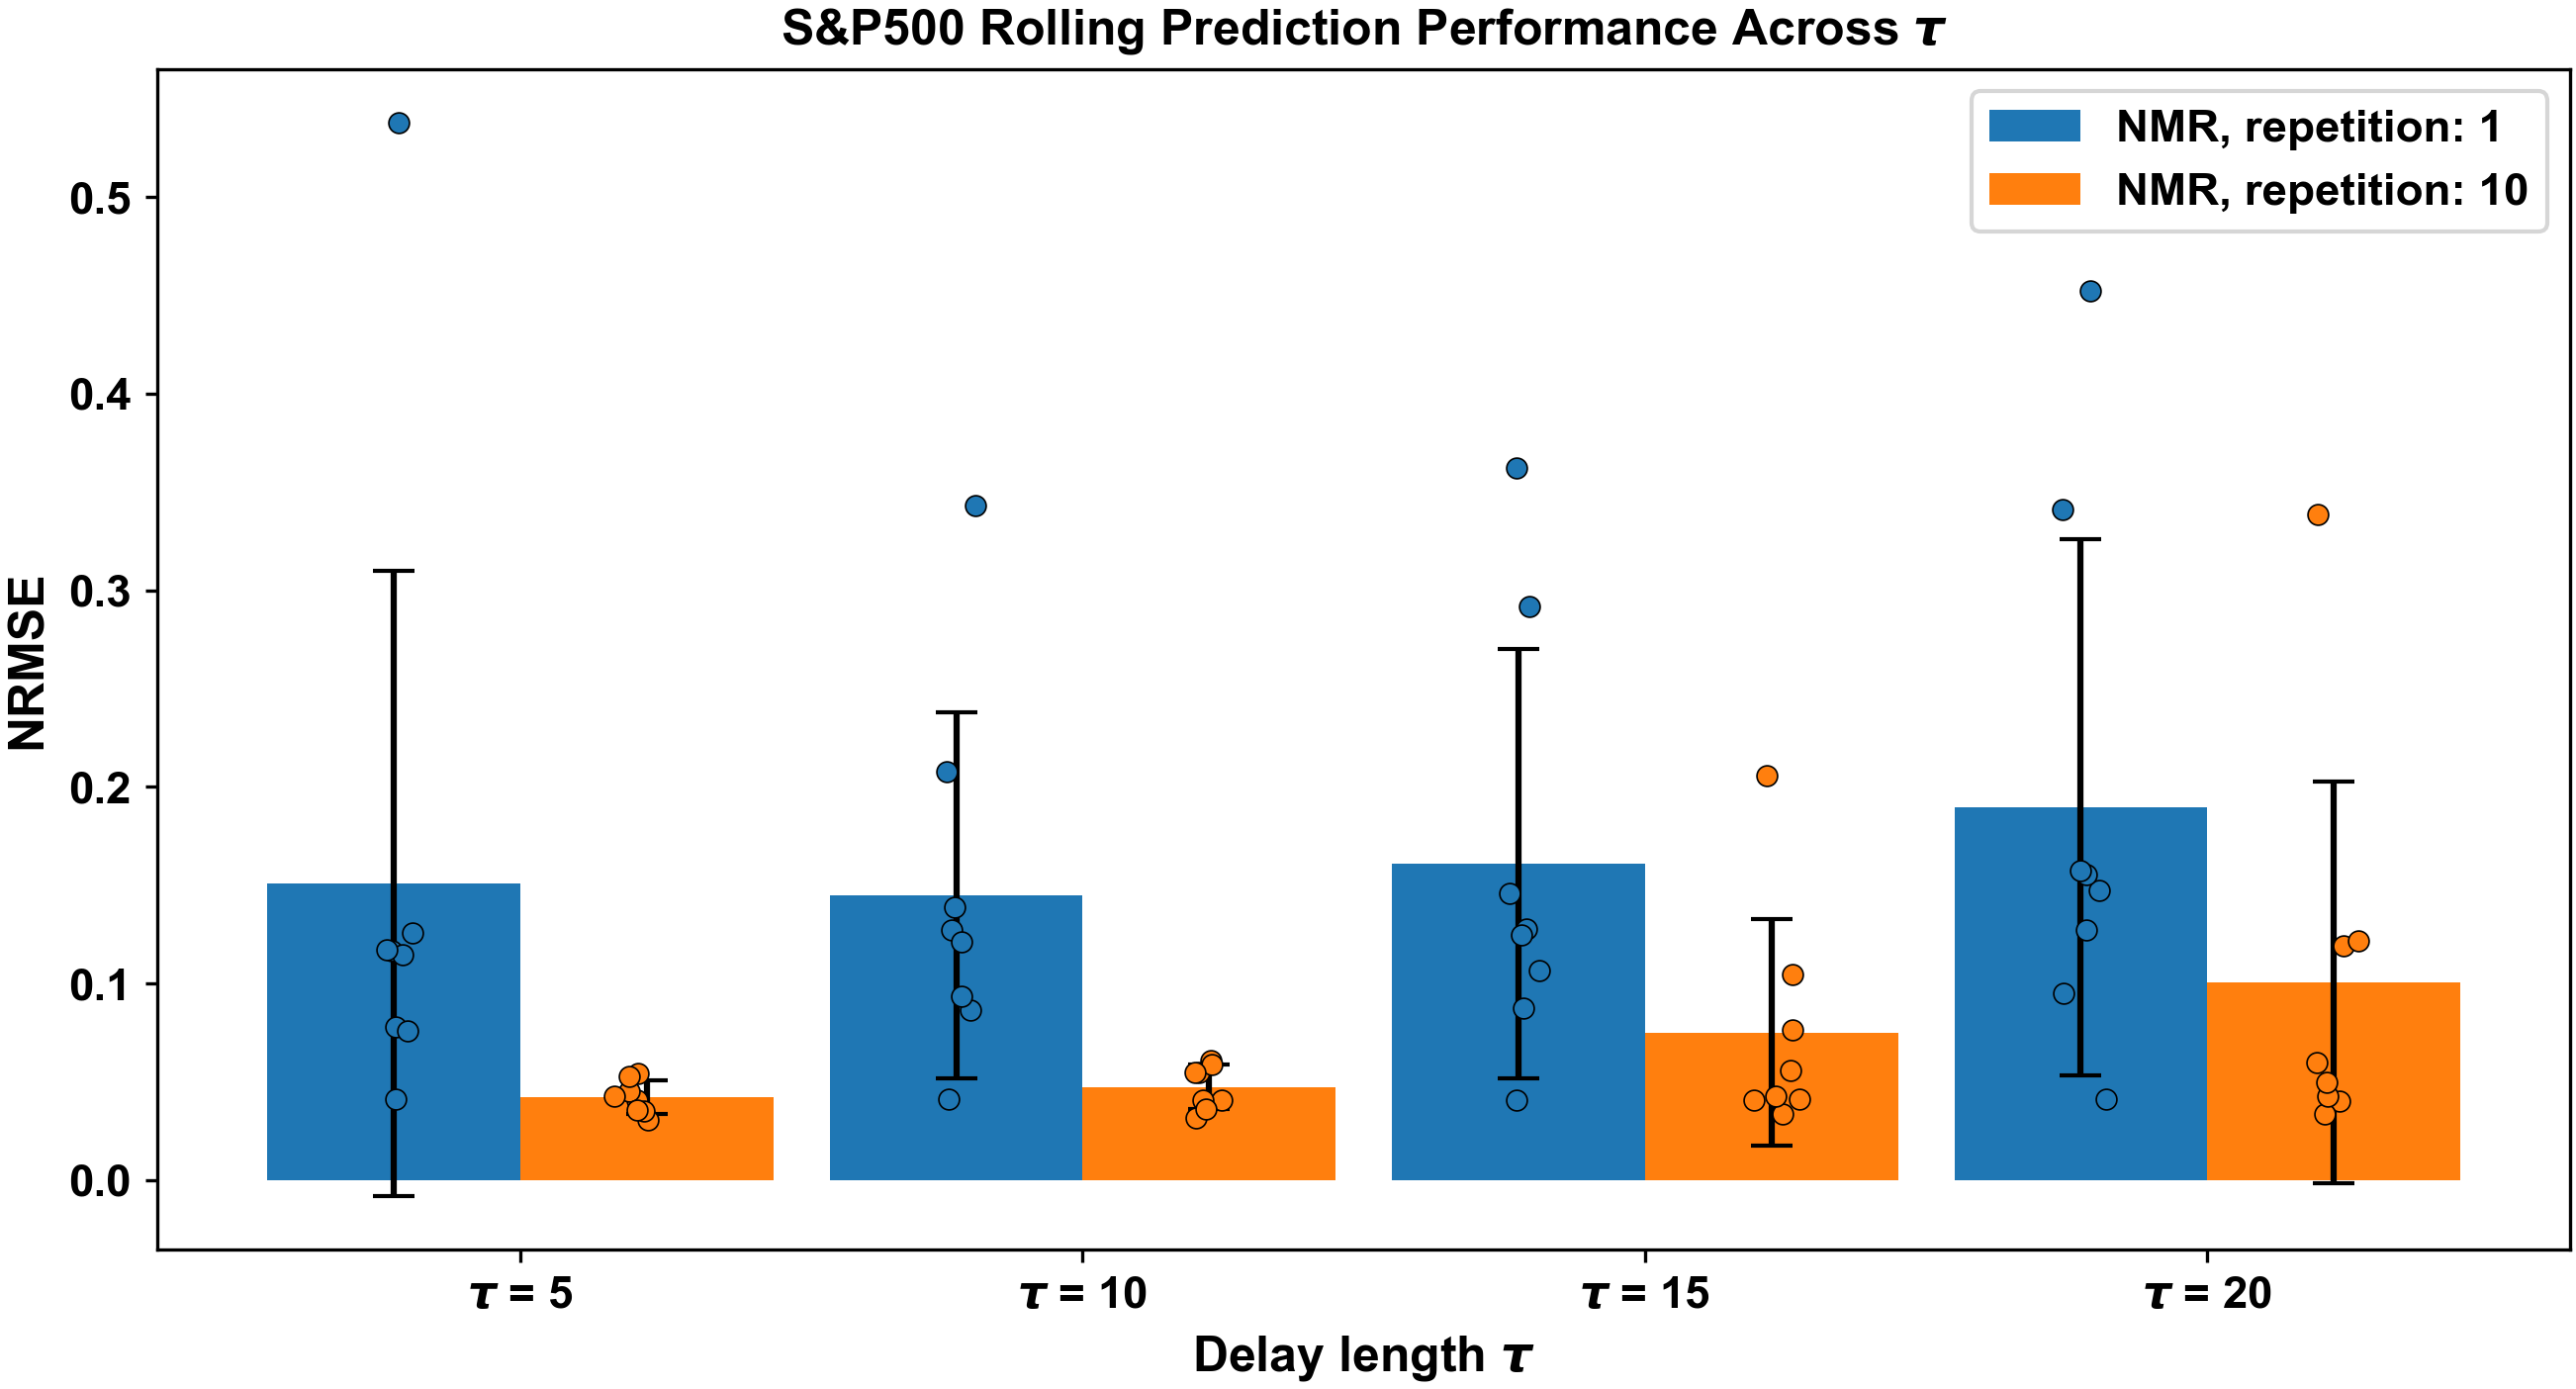

In [18]:
plt.figure(figsize=(9, 5))
width = 0.45
plt.bar(x - width / 2,rep1_means,width,yerr=rep1_stds,capsize=5,label="NMR, repetition: 1",color="tab:blue")
plt.bar(x + width / 2,rep10_means,width,yerr=rep10_stds,capsize=5,label="NMR, repetition: 10",color="tab:orange")
rng = np.random.default_rng(0)
for i, tau in enumerate(taus):
    jitter = rng.normal(0, 0.025, size=len(rep1_errors[i]))
    plt.scatter(np.full(len(rep1_errors[i]), x[i] - width / 2) + jitter,rep1_errors[i],s=25,color="tab:blue",edgecolor="black",linewidth=0.4,zorder=3)
    jitter = rng.normal(0, 0.025, size=len(rep10_errors[i]))
    plt.scatter(np.full(len(rep10_errors[i]), x[i] + width / 2) + jitter,rep10_errors[i],s=25,color="tab:orange",edgecolor="black",linewidth=0.4,zorder=3)
plt.xticks(x, [rf"$τ$ = {tau}" for tau in taus])
plt.ylabel("NRMSE")
plt.xlabel(r"Delay length $\tau$")
plt.title(r"S&P500 Rolling Prediction Performance Across $\tau$")
plt.savefig('stockprediction2.png')
plt.legend()
plt.tight_layout()
plt.show()

In [45]:
rep10_means
rep10_stds

array([0.00844196, 0.01133417, 0.05779957, 0.10217779])